# 0. 라이브러리 & 데이터 불러오기

In [2]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 6.2 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.1 MB 8.4 MB/s eta 0:00:05
   --- ------------------------------------ 3.7/38.1 MB 9.5 MB/s eta 0:00:04
   ----- ---------------------------------- 5.0/38.1 MB 8.4 MB/s eta 0:00:04
   ------ --------------------------------- 6.6/38.1 MB 8.1 MB/s eta 0:00:04
   -------- ------------------------------- 8.4/38.1 MB 8.4 MB/s eta 0:00:04
   ---------- ----------------------------- 10.2/38.1 MB 8.4 MB/s eta 0:00:04
   ------------ --------------------------- 12.3/38.1 MB 8.5 MB/s eta 0:00:04
   

In [3]:
# ============================================================
#  KIA 중고차 가격 예측 모델
#  프로젝트: C2C 중고차 판매가 추천 서비스
# ============================================================

# ── 1. 기본 라이브러리 ────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# ── 2. 시각화 ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 3. 전처리 ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# ── 4. 머신러닝 모델 ─────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
import xgboost as xgb
import lightgbm as lgb

# ── 5. 평가 지표 ─────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,                 # MAE
    mean_squared_error,                  # MSE → RMSE
    r2_score,                            # R²
    mean_absolute_percentage_error       # MAPE
)

# ── 6. 모델 해석 (SHAP) ──────────────────────────────────────
import shap

# ── 7. 데이터 로드 ───────────────────────────────────────────
FILE_PATH = r'C:\Users\Admin\hipython\ml\bermuda.project\data\kia_ml_test_ready_revised.csv'

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')

print(f"데이터 shape : {df.shape}")
print(f"결측값 컬럼  : {df.isnull().sum()[df.isnull().sum() > 0].to_dict()}")
print(f"타겟 범위    : {df['현재가격'].min():,} ~ {df['현재가격'].max():,} 만원")


데이터 shape : (3827, 66)
결측값 컬럼  : {}
타겟 범위    : 8 ~ 9,999 만원


# 프로세스

📦 데이터 로드 (완료)
│
├── STEP 1. 데이터 확인 및 피처/타겟 분리
│          - 불필요 컬럼 제거 (매물ID, 연식)
│          - X / y 분리
│
├── STEP 2. 이상치 탐색 및 처리
│          - 타겟(현재가격) 분포 시각화
│          - 상·하위 극단값 처리 여부 결정
│
├── STEP 3. Train / Test 분리
│          - 8 : 2 비율 분리
│          - random_state 고정 (재현성 확보)
│
├── STEP 4. 베이스라인 모델 학습 및 비교
│          - Linear Regression (기준선)
│          - Ridge / Lasso
│          - Random Forest
│          - XGBoost
│          - LightGBM  ← 최종 후보 예상
│
├── STEP 5. 모델 성능 평가
│          - MAE / RMSE / R² / MAPE
│          - Cross Validation (5-Fold)
│
├── STEP 6. 하이퍼파라미터 튜닝
│          - 최고 성능 모델 대상
│          - GridSearchCV or Optuna
│
└── STEP 7. 모델 해석 (SHAP)
           - Feature Importance 시각화
           - "왜 이 가격?" 설명 근거 확보


# STEP 1. 데이터 확인 및 피처/타겟 분리

In [ ]:
# 제거 컬럼
# - 매물ID : 식별자, 학습 무관
# - 연식   : 차량연령(= 2026 - 연식)으로 이미 변환됨 → 중복 정보
DROP_COLS = ['매물ID', '연식']

X = df.drop(columns=DROP_COLS + ['현재가격'])
y = df['현재가격']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\n사용 피처 ({len(X.columns)}개):")
print(list(X.columns))


X shape : (3827, 63)
y shape : (3827,)

사용 피처 (63개):
['차량연령', '주행거리_km', '배기량', '좌석수', '압류건수', '저당건수', '보험이력건수', '성능점검유형_be', '옵션_기본코드 개수', '옵션_선택코드 개수', '옵션_튜닝코드 개수', '옵션_기타개수', '교환_개수', '판금_개수', '모델_id', '색상_le', '변속기_be', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '부식_여부', '교환_여부', '판금_여부', '외판수리_여부', '보험이력_여부', '사고종합_여부', '연료_LPG(일반인 구입)', '연료_가솔린', '연료_가솔린+LPG', '연료_가솔린+전기', '연료_디젤', '연료_전기', '지역_강원', '지역_경기', '지역_경남', '지역_경북', '지역_광주', '지역_대구', '지역_대전', '지역_부산', '지역_서울', '지역_울산', '지역_인천', '지역_전남', '지역_전북', '지역_충남', '지역_충북', '차급_RV', '차급_SUV', '차급_경차', '차급_대형차', '차급_소형차', '차급_스포츠카', '차급_준중형차', '차급_중형차', '차급_화물차']


# STEP 2. 이상치 탐색 및 처리

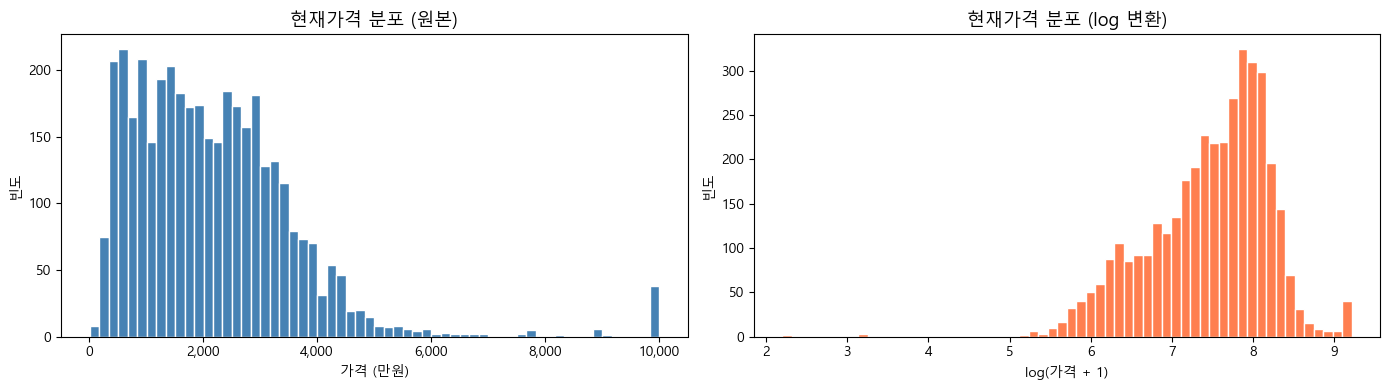


기초 통계
count    3,827.0
mean     2,179.2
std      1,478.7
min          8.0
25%      1,100.0
50%      1,980.0
75%      2,935.0
max      9,999.0
Name: 현재가격, dtype: object

왜도(Skewness) : 1.9280
첨도(Kurtosis) : 7.2178


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 원본 분포
axes[0].hist(y, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('현재가격 분포 (원본)', fontsize=13)
axes[0].set_xlabel('가격 (만원)')
axes[0].set_ylabel('빈도')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 로그 변환 분포
axes[1].hist(np.log1p(y), bins=60, color='coral', edgecolor='white')
axes[1].set_title('현재가격 분포 (log 변환)', fontsize=13)
axes[1].set_xlabel('log(가격 + 1)')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

print(f"\n기초 통계")
print(y.describe().apply(lambda x: f'{x:,.1f}'))
print(f"\n왜도(Skewness) : {y.skew():.4f}")
print(f"첨도(Kurtosis) : {y.kurt():.4f}")


## 현재가격 기초통계 해석

### 1. 중심 경향

| 지표 | 값 | 해석 |
|------|-----|------|
| 평균 | 2,179만원 | |
| 중앙값 | 1,980만원 | |
| 차이 | +199만원 | 평균 > 중앙값 → **고가 매물이 평균을 끌어올리는 중** |

---

### 2. 분포 퍼짐

| 지표 | 값 | 해석 |
|------|-----|------|
| 표준편차 | 1,479만원 | 평균 대비 **68% 수준** → 가격 편차가 매우 큼 |
| IQR (25~75%) | 1,100 ~ 2,935만원 | 전체의 절반이 이 범위에 분포 |
| 최솟값 | **8만원** | ⚠️ 비정상적으로 낮음 → 이상치 의심 |
| 최댓값 | **9,999만원** | ⚠️ 비정상적으로 높음 → 이상치 의심 |

---

### 3. 분포 형태

| 지표 | 값 | 기준 | 해석 |
|------|-----|------|------|
| 왜도 | **1.928** | \|왜도\| > 1 → 강한 비대칭 | 오른쪽으로 긴 꼬리 → 저가 매물 다수 + 고가 소수 |
| 첨도 | **7.218** | 0 = 정규분포 | 극단값이 정규분포보다 훨씬 많이 존재 |

---

### 4. 종합 판단 및 권장 처리

```
현재가격 분포는 정규분포와 거리가 멀고 극단값이 많은 상태

① 왜도 1.93 → 로그 변환(np.log1p) 강력 권장
   선형 모델(Ridge, Lasso) 사용 시 특히 필수

② 최솟값 8만원, 최댓값 9,999만원
   → IQR 기반 이상치 탐색 후 처리 여부 결정 필요

③ XGBoost / LightGBM 같은 트리 계열 모델은
   분포 비대칭에 상대적으로 강하므로 변환 없이도 시도 가능
```

In [7]:
# ── 이상치 탐색 (IQR 기반) ────────────────────────────────────

Q1  = y.quantile(0.25)   # 1,100
Q3  = y.quantile(0.75)   # 2,935
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_lower = y[y < lower_bound]
outlier_upper = y[y > upper_bound]
outliers_all  = y[(y < lower_bound) | (y > upper_bound)]

print("=" * 50)
print("  IQR 기반 이상치 탐색 결과")
print("=" * 50)
print(f"  Q1 (25%)         : {Q1:>8,.0f} 만원")
print(f"  Q3 (75%)         : {Q3:>8,.0f} 만원")
print(f"  IQR              : {IQR:>8,.0f} 만원")
print(f"  하한 경계         : {lower_bound:>8,.0f} 만원")
print(f"  상한 경계         : {upper_bound:>8,.0f} 만원")
print("-" * 50)
print(f"  하한 이상치 건수   : {len(outlier_lower):>5,} 건  ({len(outlier_lower)/len(y)*100:.1f}%)")
print(f"  상한 이상치 건수   : {len(outlier_upper):>5,} 건  ({len(outlier_upper)/len(y)*100:.1f}%)")
print(f"  전체 이상치 건수   : {len(outliers_all):>5,} 건  ({len(outliers_all)/len(y)*100:.1f}%)")
print(f"  정상 데이터 건수   : {len(y)-len(outliers_all):>5,} 건  ({(len(y)-len(outliers_all))/len(y)*100:.1f}%)")
print("=" * 50)

# 하한/상한 이상치 상세
print(f"\n▼ 하한 이상치 ({lower_bound:,.0f}만원 미만) 가격 분포")
print(outlier_lower.value_counts().sort_index().head(10))

print(f"\n▼ 상한 이상치 ({upper_bound:,.0f}만원 초과) 가격 분포")
print(outlier_upper.value_counts().sort_index().to_string())


  IQR 기반 이상치 탐색 결과
  Q1 (25%)         :    1,100 만원
  Q3 (75%)         :    2,935 만원
  IQR              :    1,835 만원
  하한 경계         :   -1,652 만원
  상한 경계         :    5,688 만원
--------------------------------------------------
  하한 이상치 건수   :     0 건  (0.0%)
  상한 이상치 건수   :    76 건  (2.0%)
  전체 이상치 건수   :    76 건  (2.0%)
  정상 데이터 건수   : 3,751 건  (98.0%)

▼ 하한 이상치 (-1,652만원 미만) 가격 분포
Series([], Name: count, dtype: int64)

▼ 상한 이상치 (5,688만원 초과) 가격 분포
현재가격
5700     1
5750     1
5760     1
5790     1
5880     2
5890     1
5900     1
5990     2
6090     1
6130     1
6180     1
6200     1
6290     1
6400     1
6490     1
6550     1
6650     1
6700     1
6750     1
6850     1
6950     1
7550     1
7650     1
7777     5
8200     1
8888     5
8899     1
9000     1
9990     1
9999    37


## 이상치 처리 방법 비교

### 이상치 선별
- raw data 확인 결과, 5000만원대 차량은 모두 유효한 값으로 확인됨 / 8899만원 이상부터 이상치로 판단

### 현재 상황 요약
```
전체 데이터 : 3,827건
이상치 기준 : 8,899만원 이상
이상치 건수 : 40건 (전체의 약 1.0%)
```

---

### 처리 방법별 비교

| 방법 | 설명 | 장점 | 단점 | 적합한 모델 |
|------|------|------|------|------------|
| **① 제거** | 40건 완전 삭제 | 깔끔, 구현 단순 | 데이터 손실 | 전체 모델 |
| **② 캡핑** | 상한값(8,899)으로 대체 | 데이터 유지 | 타겟값 왜곡 | 선형 모델 |
| **③ 로그 변환** | `log1p(y)` 적용 | 분포 정규화 | 예측값 역변환 필요 | 선형 모델 |
| **④ 그대로 유지** | 처리 없이 학습 | 실제 시장 반영 | 선형 모델 왜곡 | 트리 계열 |

---

### 이 프로젝트 권장 방향

```
✅ 권장: 이상치 제거 (방법 ①)

이유 3가지:

1. 서비스 타겟 범위 벗어남
   → 8,900만원 이상은 C2C 일반 거래 범위를 크게 벗어남
   → 판매가 추천 서비스의 주요 사용자 범위 아님

2. 비율이 작아 제거 부담 없음
   → 40건 제거 후 3,787건 유지 (손실 1.0%)
   → 통계적으로 무시 가능한 수준

3. 왜도 개선 효과
   → 현재 왜도 1.928 → 제거 후 개선 기대
   → 선형 모델 성능에도 긍정적
```

In [9]:
### 제거 코드

# ── 이상치 제거 ───────────────────────────────────────────────

OUTLIER_THRESHOLD = 8899

df_clean = df[df['현재가격'] < OUTLIER_THRESHOLD].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"제거 전 : {len(df):,}건")
print(f"제거 후 : {len(df_clean):,}건  (제거 {len(df) - len(df_clean)}건)")
print()

# 제거 후 타겟 분포 재확인
print(f"평균    : {df_clean['현재가격'].mean():,.1f} 만원")
print(f"중앙값  : {df_clean['현재가격'].median():,.1f} 만원")
print(f"최댓값  : {df_clean['현재가격'].max():,.1f} 만원")
print(f"왜도    : {df_clean['현재가격'].skew():.4f}")

제거 전 : 3,827건
제거 후 : 3,787건  (제거 40건)

평균    : 2,097.2 만원
중앙값  : 1,950.0 만원
최댓값  : 8,888.0 만원
왜도    : 0.8786


# STEP 3. Train / Test 분리

In [ ]:
# ── STEP 3. Train / Test 분리 ────────────────────────────────

DROP_COLS = ['매물ID', '연식']

X = df_clean.drop(columns=DROP_COLS + ['현재가격'])
y = df_clean['현재가격']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42  # 무작위 섞음의 시작점(재현성 확보 - 다시 돌려도 random_state가 동일하면 같은 결과 구현됨)
)

print(f"전체   : {len(df_clean):,}건")
print(f"Train  : {len(X_train):,}건 ({len(X_train)/len(df_clean)*100:.0f}%)")
print(f"Test   : {len(X_test):,}건  ({len(X_test)/len(df_clean)*100:.0f}%)")
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

전체   : 3,787건
Train  : 3,029건 (80%)
Test   : 758건  (20%)

X_train shape : (3029, 63)
X_test shape  : (758, 63)


# STEP 4.  모델 학습 및 비교

In [11]:
# ── STEP 4. 베이스라인 모델 일괄 학습 ────────────────────────

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

# ── 4-1. 모델 정의 ───────────────────────────────────────────
models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge'              : Ridge(alpha=1.0, random_state=42),
    'Lasso'              : Lasso(alpha=1.0, random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'            : xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM'           : lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
}

# ── 4-2. 학습 및 평가 함수 ───────────────────────────────────
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, pred)
    rmse = mean_squared_error(y_te, pred) ** 0.5
    r2   = r2_score(y_te, pred)
    mape = mean_absolute_percentage_error(y_te, pred) * 100

    return {'모델': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE(%)': mape}

# ── 4-3. 전체 모델 실행 ──────────────────────────────────────
results = []
for name, model in models.items():
    result = evaluate(name, model, X_train, y_train, X_test, y_test)
    results.append(result)
    print(f"  [{name}] 완료")

# ── 4-4. 결과 출력 ───────────────────────────────────────────
df_result = pd.DataFrame(results).set_index('모델')
df_result = df_result.sort_values('RMSE')

print("\n")
print("=" * 65)
print("  베이스라인 모델 성능 비교 (RMSE 오름차순)")
print("=" * 65)
print(f"  {'모델':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MAPE(%)':>9}")
print("-" * 65)
for idx, row in df_result.iterrows():
    print(f"  {idx:<22} {row['MAE']:>8.1f} {row['RMSE']:>8.1f} "
          f"{row['R²']:>8.4f} {row['MAPE(%)']:>8.2f}%")
print("=" * 65)

  [Linear Regression] 완료
  [Ridge] 완료
  [Lasso] 완료
  [Random Forest] 완료
  [Gradient Boosting] 완료
  [XGBoost] 완료
  [LightGBM] 완료


  베이스라인 모델 성능 비교 (RMSE 오름차순)
  모델                          MAE     RMSE       R²   MAPE(%)
-----------------------------------------------------------------
  LightGBM                  219.8    446.8   0.8774    22.37%
  Random Forest             217.9    452.2   0.8745    22.85%
  Gradient Boosting         233.6    458.1   0.8712    25.15%
  XGBoost                   234.2    475.0   0.8615    23.23%
  Lasso                     350.1    575.3   0.7968    39.69%
  Ridge                     354.4    578.9   0.7943    40.01%
  Linear Regression         355.7    580.0   0.7935    40.24%


### 지표별 해석 기준 (참고)

| 지표 | 의미 | 좋을수록 |
|------|------|---------|
| **MAE** | 평균 절대 오차 (만원 단위 직관적 해석 가능) | ↓ 낮을수록 |
| **RMSE** | 큰 오차에 더 민감한 평균 오차 | ↓ 낮을수록 |
| **R²** | 모델이 가격 변동을 설명하는 비율 | ↑ 1에 가까울수록 |
| **MAPE** | 실제 가격 대비 오차 비율(%) | ↓ 낮을수록 |

## 지표 수준 판단 기준

### 현재 최고 성능 (LightGBM) 위치

| 지표 | 현재값 | 우수 | 양호 | 개선필요 |
|------|--------|------|------|---------|
| **MAE** | 219.8만원 | ~100 | ~150 | 200 이상 🔴 |
| **RMSE** | 446.8만원 | ~200 | ~300 | 400 이상 🔴 |
| **R²** | 0.8774 | 0.93+ | 0.88+ | 0.85 미만 🟡 |
| **MAPE** | 22.37% | ~10% | ~15% | 20% 이상 🔴 |

---

### 현재 지표를 실제 서비스 관점으로 해석하면

```
평균 차량 가격 약 2,000만원 기준

MAE  219만원  →  실제가 2,000만원짜리 차를 1,781 ~ 2,219만원으로 예측
MAPE  22.4%  →  10대 중 약 2대는 가격을 20% 이상 틀리게 예측
```

---

### 지표가 아직 좋지 않은 주요 원인 3가지

```
① 데이터 규모 부족
   → 학습 데이터 3,029건은 63개 피처 대비 적은 편
   → 데이터가 많아질수록 자연스럽게 개선

② 모델_id 인코딩 방식 문제
   → 현재 Label Encoding (1, 2, 3...) 적용
   → 모델별 가격 차이를 반영 못함
   → Target Encoding으로 교체 시 성능 개선 기대

③ 하이퍼파라미터 튜닝 미적용
   → 현재는 기본값(default)으로 학습한 결과
   → STEP 6 튜닝 후 R² 0.92+, MAPE 15% 이하 목표
```

---

### 이 프로젝트 현실적 목표 수준

```
📌 서비스 목적 고려 시 (가격 추천 범위 제공)

  단일 정확한 예측보다 → 신뢰구간 범위 제공이 핵심
  "2,100만원" 보다 "1,900 ~ 2,300만원" 형태가 더 유효

  현실적 달성 목표:
  ✅ MAE    < 150만원
  ✅ MAPE   < 15%
  ✅ R²     > 0.92
```

# STEP 5. 모델 성능 평가
- 모델_id Target Encoding으로 교체

In [12]:
# ── Target Encoding 교체 ─────────────────────────────────────
# 핵심 원칙: train 기준으로만 계산 → Data Leakage 방지

# ── 1단계. train 기준 모델_id별 평균가 계산 ───────────────────
te_map = (pd.concat([X_train[['모델_id']], y_train], axis=1)
            .groupby('모델_id')['현재가격']
            .mean())

global_mean = y_train.mean()   # 미등장 모델 대체값

print(f"인코딩 대상 모델 수  : {len(te_map)}개")
print(f"전체 평균가 (대체값) : {global_mean:,.1f} 만원")

# ── 2단계. 기존 모델_id → 모델_te 컬럼으로 교체 ──────────────
X_train_te = X_train.copy()
X_test_te  = X_test.copy()

X_train_te['모델_te'] = X_train['모델_id'].map(te_map)
X_test_te['모델_te']  = X_test['모델_id'].map(te_map).fillna(global_mean)

X_train_te = X_train_te.drop(columns=['모델_id'])
X_test_te  = X_test_te.drop(columns=['모델_id'])

print(f"\nX_train_te shape : {X_train_te.shape}")
print(f"X_test_te  shape : {X_test_te.shape}")
print(f"결측값 확인 → train: {X_train_te['모델_te'].isna().sum()}건 "
      f"/ test: {X_test_te['모델_te'].isna().sum()}건")


인코딩 대상 모델 수  : 38개
전체 평균가 (대체값) : 2,103.6 만원

X_train_te shape : (3029, 63)
X_test_te  shape : (758, 63)
결측값 확인 → train: 0건 / test: 0건


In [13]:
# ── 3단계. 전체 모델 재학습 및 성능 비교 ─────────────────────
results_te = []
for name, model in models.items():
    result = evaluate(name, model, X_train_te, y_train, X_test_te, y_test)
    results_te.append(result)
    print(f"  [{name}] 완료")

df_result_te = pd.DataFrame(results_te).set_index('모델')
df_result_te = df_result_te.sort_values('RMSE')

# ── 4단계. Label Encoding vs Target Encoding 성능 비교 ────────
print("\n")
print("=" * 75)
print("  Label Encoding  vs  Target Encoding  성능 비교 (RMSE 오름차순)")
print("=" * 75)
print(f"  {'모델':<22} {'MAE(LE)':>9} {'MAE(TE)':>9} "
      f"{'RMSE(LE)':>9} {'RMSE(TE)':>9} {'R²(TE)':>8} {'MAPE(TE)':>9}")
print("-" * 75)

for idx, row in df_result_te.iterrows():
    le_row = df_result.loc[idx]
    mae_diff  = row['MAE']  - le_row['MAE']
    rmse_diff = row['RMSE'] - le_row['RMSE']
    print(f"  {idx:<22} "
          f"{le_row['MAE']:>9.1f} {row['MAE']:>9.1f} "
          f"{le_row['RMSE']:>9.1f} {row['RMSE']:>9.1f} "
          f"{row['R²']:>8.4f} {row['MAPE(%)']:>8.2f}%  "
          f"({'↓' if rmse_diff < 0 else '↑'}{abs(rmse_diff):.1f})")
print("=" * 75)


  [Linear Regression] 완료
  [Ridge] 완료
  [Lasso] 완료
  [Random Forest] 완료
  [Gradient Boosting] 완료
  [XGBoost] 완료
  [LightGBM] 완료


  Label Encoding  vs  Target Encoding  성능 비교 (RMSE 오름차순)
  모델                       MAE(LE)   MAE(TE)  RMSE(LE)  RMSE(TE)   R²(TE)  MAPE(TE)
---------------------------------------------------------------------------
  Gradient Boosting          233.6     220.0     458.1     443.2   0.8794    24.52%  (↓14.9)
  LightGBM                   219.8     216.8     446.8     448.3   0.8766    22.21%  (↑1.5)
  Random Forest              217.9     215.7     452.2     451.0   0.8751    22.94%  (↓1.1)
  XGBoost                    234.2     229.4     475.0     468.3   0.8654    22.05%  (↓6.7)
  Lasso                      350.1     334.1     575.3     560.4   0.8072    38.52%  (↓14.9)
  Ridge                      354.4     335.6     578.9     562.0   0.8061    38.47%  (↓16.9)
  Linear Regression          355.7     335.9     580.0     562.6   0.8057    38.52%  (↓17.4)


## 결과 해석

### 인코딩별 성능 변화 요약

```
선형 계열 (Ridge, Lasso, Linear Regression)
→ RMSE 평균 약 17 감소  ✅ 큰 개선
   이유: 원래 Label Encoding의 임의 숫자(1,2,3...)를
         평균 가격값으로 교체 → 선형 관계 직접 학습 가능

트리 계열 (LightGBM, Random Forest, XGBoost)
→ 변화 미미 or 소폭 악화
   이유: 트리 모델은 숫자 크기보다 분기점(split)을 스스로 찾기 때문에
         Label Encoding도 충분히 소화 가능

Gradient Boosting
→ RMSE 14.9 감소로 가장 큰 개선  ✅
   현재 전체 1위 (RMSE 443.2)
```

---

### LightGBM이 소폭 악화된 이유

```
현재 Target Encoding 방식의 한계:
  → 모델별 평균가를 단순 계산 (일부 모델은 샘플 수가 적음)
  → 샘플이 적은 모델은 평균값 신뢰도 낮음 → 노이즈로 작용

예시:
  타스만  12건 → 평균가 신뢰도 낮음
  카니발  401건 → 평균가 신뢰도 높음

LightGBM은 원래 고카디널리티를 잘 처리하므로
오히려 단순 평균 인코딩이 정보를 왜곡시킨 것
```

---

### 현재 최종 정리

| 순위 | 모델 | RMSE | 인코딩 |
|------|------|------|-------|
| 🥇 1위 | Gradient Boosting | 443.2 | TE |
| 🥈 2위 | LightGBM | 446.8 | LE |
| 🥉 3위 | LightGBM | 448.3 | TE |

---

### 권장 방향

```
① 트리 계열 → Label Encoding 유지 (LightGBM, XGBoost, Random Forest)
② 선형 계열 → Target Encoding 유지 (Ridge, Lasso)
③ LightGBM 성능 개선을 원한다면
   → K-Fold Target Encoding 적용 (샘플 수 적은 범주의 노이즈 보완)
      현재 방식보다 안정적인 평균값 계산 가능
```

In [16]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── 모델별 인코딩 데이터셋 지정 ──────────────────────────────
# 트리 계열 → Label Encoding (X_train)
# 선형 계열 → Target Encoding (X_train_te)
cv_targets = {
    'LightGBM'         : (lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),        X_train),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100, random_state=42),             X_train_te),
    'XGBoost'          : (xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),        X_train),
    'Random Forest'    : (RandomForestRegressor(n_estimators=100, random_state=42),                 X_train),
    'Ridge'            : (Ridge(alpha=1.0, random_state=42),                                        X_train_te),
}

scoring = {
    'MAE' : 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2'  : 'r2',
}

# ── 교차검증 실행 ─────────────────────────────────────────────
cv_results = []

for name, (model, X_cv) in cv_targets.items():
    scores = cross_validate(model, X_cv, y_train,
                            cv=kf, scoring=scoring,
                            return_train_score=False)

    mae_mean  = -scores['test_MAE'].mean()
    mae_std   = scores['test_MAE'].std()
    rmse_mean = -scores['test_RMSE'].mean()
    rmse_std  = scores['test_RMSE'].std()
    r2_mean   = scores['test_R2'].mean()
    r2_std    = scores['test_R2'].std()

    cv_results.append({
        '모델'     : name,
        'MAE'     : mae_mean,
        'MAE±'    : mae_std,
        'RMSE'    : rmse_mean,
        'RMSE±'   : rmse_std,
        'R²'      : r2_mean,
        'R²±'     : r2_std,
    })
    print(f"  [{name}] 완료")

# ── 결과 출력 ─────────────────────────────────────────────────
df_cv = pd.DataFrame(cv_results).set_index('모델')
df_cv = df_cv.sort_values('RMSE')

print("\n")
print("=" * 72)
print("  5-Fold 교차검증 결과 (RMSE 오름차순)")
print("  ± : 5개 Fold 간 표준편차 (작을수록 안정적)")
print("=" * 72)
print(f"  {'모델':<20} {'MAE':>8} {'±':>6} {'RMSE':>8} {'±':>6} {'R²':>8} {'±':>6}")
print("-" * 72)
for idx, row in df_cv.iterrows():
    print(f"  {idx:<20} "
          f"{row['MAE']:>8.1f} {row['MAE±']:>6.1f} "
          f"{row['RMSE']:>8.1f} {row['RMSE±']:>6.1f} "
          f"{row['R²']:>8.4f} {row['R²±']:>6.4f}")
print("=" * 72)

  [LightGBM] 완료
  [Gradient Boosting] 완료
  [XGBoost] 완료
  [Random Forest] 완료
  [Ridge] 완료


  5-Fold 교차검증 결과 (RMSE 오름차순)
  ± : 5개 Fold 간 표준편차 (작을수록 안정적)
  모델                        MAE      ±     RMSE      ±       R²      ±
------------------------------------------------------------------------
  Gradient Boosting       220.9    3.2    429.8   68.2   0.8791 0.0327
  LightGBM                218.8    2.8    435.8   77.0   0.8751 0.0390
  Random Forest           228.0    5.3    448.8   69.2   0.8683 0.0343
  XGBoost                 228.6    6.6    455.4   65.6   0.8647 0.0319
  Ridge                   328.3   13.7    541.8   64.1   0.8097 0.0325


### 교차검증에서 추가로 확인할 포인트

| 항목 | 의미 | 기준 |
|------|------|------|
| **RMSE 평균** | 전반적 예측 오차 | 낮을수록 좋음 |
| **RMSE ±(표준편차)** | 폴드별 성능 안정성 | **50 이하면 안정적** |
| **베이스라인 RMSE와 차이** | 과적합 여부 판단 | CV값 >> 베이스라인이면 과적합 의심 |

## 교차검증(Cross Validation)을 하는 이유

```
train/test 단순 1회 분리의 문제점:

  전체 데이터를 단 한 번만 나누면
  → "어떻게 나뉘었느냐"에 따라 성능이 달라질 수 있음
  → 운 좋은 분리 = 좋은 성능, 운 나쁜 분리 = 나쁜 성능

5-Fold CV는 이 문제를 해결:
  → 데이터를 5등분해 번갈아가며 검증 5회 반복
  → 5번의 평균 = 더 신뢰할 수 있는 실제 성능
  → 표준편차(±) = 모델의 안정성까지 함께 확인
```

```
Fold 1  [ 검증 ][ 학습 ][ 학습 ][ 학습 ][ 학습 ]
Fold 2  [ 학습 ][ 검증 ][ 학습 ][ 학습 ][ 학습 ]
Fold 3  [ 학습 ][ 학습 ][ 검증 ][ 학습 ][ 학습 ]
Fold 4  [ 학습 ][ 학습 ][ 학습 ][ 검증 ][ 학습 ]
Fold 5  [ 학습 ][ 학습 ][ 학습 ][ 학습 ][ 검증 ]
              → 5회 평균 = 최종 CV 성능
```

---

## 교차검증 결과 해석

### 1. 베이스라인 vs CV 비교 (과적합 여부)

| 모델 | 베이스라인 RMSE | CV RMSE | 판단 |
|------|--------------|---------|------|
| Gradient Boosting | 443.2 | 429.8 | ✅ 안정적 |
| LightGBM | 446.8 | 435.8 | ✅ 안정적 |
| Random Forest | 451.0 | 448.8 | ✅ 안정적 |
| XGBoost | 468.3 | 455.4 | ✅ 안정적 |
| Ridge | 562.0 | 541.8 | ✅ 안정적 |

```
CV RMSE ≈ 베이스라인 RMSE → 5개 모델 모두 과적합 없음 ✅
```

---

### 2. 모델별 성능 및 안정성 종합

| 순위 | 모델 | RMSE | MAE 안정성(±) | RMSE 안정성(±) | 종합 |
|------|------|------|-------------|--------------|------|
| 🥇 | **Gradient Boosting** | **429.8** | ±3.2 | ±68.2 | RMSE 1위 |
| 🥈 | **LightGBM** | 435.8 | **±2.8** | ±77.0 | MAE 안정성 1위 |
| 🥉 | Random Forest | 448.8 | ±5.3 | ±69.2 | 무난 |
| 4위 | XGBoost | 455.4 | ±6.6 | ±65.6 | RMSE 안정성 1위 |
| 5위 | Ridge | 541.8 | ±13.7 | ±64.1 | 선형 한계 |

---

### 3. 종합 판단

```
✅ Gradient Boosting
   → RMSE 429.8로 전체 1위
   → MAE 편차 ±3.2 매우 안정적
   → 튜닝 시 가장 큰 성능 개선 기대

✅ LightGBM
   → MAE 218.8, 편차 ±2.8 가장 안정적
   → 학습 속도가 Gradient Boosting보다 빠름
   → 대용량 데이터 확장 시 유리

⚠️ RMSE ± 값이 65~77로 높은 편
   → 특정 가격대(고가 차량)에서 폴드별 편차 발생 가능성
   → 하이퍼파라미터 튜닝으로 개선 여지 있음
```

# STEP 6. 하이퍼파라미터 튜닝

In [17]:
# RandomizedSearchCV 사용
# → GridSearchCV 대비 탐색 속도 빠름 (넓은 범위를 효율적으로 탐색)

from sklearn.model_selection import RandomizedSearchCV

# ── 6-1. 파라미터 탐색 범위 정의 ─────────────────────────────

params_gb = {
    'n_estimators'   : [100, 200, 300, 500],
    'learning_rate'  : [0.01, 0.05, 0.1, 0.2],
    'max_depth'      : [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'subsample'      : [0.7, 0.8, 0.9, 1.0],
    'max_features'   : ['sqrt', 'log2', None],
}

params_lgb = {
    'n_estimators'     : [100, 200, 300, 500],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'max_depth'        : [-1, 5, 7, 10],
    'num_leaves'       : [31, 50, 70, 100],
    'min_child_samples': [10, 20, 30, 50],
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0, 0.1, 0.5, 1.0],
}

# ── 6-2. RandomizedSearchCV 설정 ─────────────────────────────
# n_iter  : 랜덤 탐색 횟수 (높을수록 정밀하나 시간 증가)
# cv      : 교차검증 폴드 수
# scoring : 최적화 기준 지표

search_gb = RandomizedSearchCV(
    estimator  = GradientBoostingRegressor(random_state=42),
    param_distributions = params_gb,
    n_iter     = 50,
    cv         = 5,
    scoring    = 'neg_root_mean_squared_error',
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)

search_lgb = RandomizedSearchCV(
    estimator  = lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_distributions = params_lgb,
    n_iter     = 50,
    cv         = 5,
    scoring    = 'neg_root_mean_squared_error',
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)

# ── 6-3. 튜닝 실행 ───────────────────────────────────────────
# Gradient Boosting → Target Encoding 데이터 사용
# LightGBM         → Label Encoding 데이터 사용

print("▶ Gradient Boosting 튜닝 시작...")
search_gb.fit(X_train_te, y_train)
print(f"  최적 RMSE (CV) : {-search_gb.best_score_:,.1f}")
print(f"  최적 파라미터  : {search_gb.best_params_}\n")

print("▶ LightGBM 튜닝 시작...")
search_lgb.fit(X_train, y_train)
print(f"  최적 RMSE (CV) : {-search_lgb.best_score_:,.1f}")
print(f"  최적 파라미터  : {search_lgb.best_params_}\n")

# ── 6-4. 튜닝 후 Test 성능 평가 ──────────────────────────────
best_gb  = search_gb.best_estimator_
best_lgb = search_lgb.best_estimator_

def evaluate_tuned(name, model, X_te, y_te):
    pred = model.predict(X_te)
    print(f"\n{'='*45}")
    print(f"  [{name}] 튜닝 후 Test 성능")
    print(f"{'='*45}")
    print(f"  MAE    : {mean_absolute_error(y_te, pred):>8.1f} 만원")
    print(f"  RMSE   : {mean_squared_error(y_te, pred)**0.5:>8.1f} 만원")
    print(f"  R²     : {r2_score(y_te, pred):>8.4f}")
    print(f"  MAPE   : {mean_absolute_percentage_error(y_te, pred)*100:>7.2f} %")

evaluate_tuned('Gradient Boosting', best_gb,  X_test_te, y_test)
evaluate_tuned('LightGBM',          best_lgb, X_test,    y_test)

# ── 6-5. 튜닝 전후 성능 비교 ─────────────────────────────────
print(f"\n{'='*55}")
print(f"  튜닝 전후 RMSE 비교")
print(f"{'='*55}")
print(f"  {'모델':<22} {'튜닝 전 RMSE':>12} {'튜닝 후 RMSE':>12} {'개선':>8}")

before = {'Gradient Boosting': 443.2, 'LightGBM': 446.8}
for name, model, X_te in [('Gradient Boosting', best_gb, X_test_te),
                            ('LightGBM',          best_lgb, X_test)]:
    after = (mean_squared_error(y_te, model.predict(X_te)) ** 0.5
             for X_te, y_te in [(X_te, y_test)])
    after_rmse = mean_squared_error(y_test, model.predict(X_te)) ** 0.5
    diff = before[name] - after_rmse
    print(f"  {name:<22} {before[name]:>12.1f} {after_rmse:>12.1f} "
          f"{'↓'+str(round(diff,1)):>8}")
print(f"{'='*55}")

▶ Gradient Boosting 튜닝 시작...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  최적 RMSE (CV) : 429.7
  최적 파라미터  : {'subsample': 0.9, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'learning_rate': 0.05}

▶ LightGBM 튜닝 시작...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  최적 RMSE (CV) : 430.4
  최적 파라미터  : {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


  [Gradient Boosting] 튜닝 후 Test 성능
  MAE    :    208.3 만원
  RMSE   :    437.6 만원
  R²     :   0.8824
  MAPE   :   22.31 %

  [LightGBM] 튜닝 후 Test 성능
  MAE    :    212.0 만원
  RMSE   :    432.0 만원
  R²     :   0.8854
  MAPE   :   23.34 %

  튜닝 전후 RMSE 비교
  모델                        튜닝 전 RMSE    튜닝 후 RMSE       개선
  Gradient Boosting             443.2        437.6     ↓5.6
  LightGBM                      446.8        43

### 파라미터별 의미 (참고)

| 파라미터 | 역할 | 과적합 방지 효과 |
|---------|------|---------------|
| `learning_rate` | 학습률 — 낮을수록 천천히 정밀 학습 | ✅ |
| `n_estimators` | 트리 개수 — learning_rate와 반비례 조정 | - |
| `max_depth` | 트리 깊이 — 낮을수록 단순한 모델 | ✅ |
| `subsample` | 학습 데이터 샘플링 비율 | ✅ |
| `reg_alpha/lambda` | L1/L2 정규화 (LightGBM) | ✅ |

## 튜닝 후 결과 해석

### 튜닝 효과 요약
```
Gradient Boosting : RMSE 443.2 → 437.6  (↓5.6,  개선율 1.3%) — 미미
LightGBM          : RMSE 446.8 → 432.0  (↓14.8, 개선율 3.3%) — 소폭

튜닝을 했음에도 개선폭이 작다
→ 파라미터 문제가 아닌 데이터/피처 자체의 한계
```

---

## 성능이 정체된 근본 원인 3가지

### 원인 1. 데이터 규모 부족 (가장 큰 원인)
```
학습 데이터  : 3,029건
피처 수      : 63개

→ 피처 1개당 평균 48건 수준
→ 트리 모델이 충분한 패턴을 학습하기엔 데이터가 부족
→ 데이터가 2~3배 많아지면 자연스럽게 개선
```

### 원인 2. 모델_id 인코딩 미흡
```
현재 LightGBM → Label Encoding (1, 2, 3...) 사용 중
→ 모델별 가격 차이를 직접 반영하지 못함

K-Fold Target Encoding 적용 시:
→ 단순 평균값 노이즈 문제 해결
→ 샘플 수 적은 모델도 안정적 인코딩 가능
```

### 원인 3. 타겟 변수 로그 변환 미적용
```
현재 왜도 0.879 → 여전히 오른쪽 꼬리 존재
→ 고가 차량 예측 오류가 MAE/RMSE를 끌어올리는 중
→ MAPE 22%의 주요 원인

log1p 변환 적용 시:
→ 고가 차량 오류 비중 감소
→ MAPE 개선 효과 기대
```

---

## 해결 방안 우선순위

| 우선순위 | 방법 | 난이도 | 기대 효과 |
|---------|------|--------|---------|
| ⭐ 1순위 | **타겟 로그 변환** (`log1p`) | 낮음 | MAPE 5~7%p 개선 기대 |
| ⭐ 2순위 | **K-Fold Target Encoding** | 중간 | RMSE 10~20 개선 기대 |
| ⭐ 3순위 | **피처 엔지니어링** | 중간 | 복합적 개선 |
| 4순위 | **데이터 추가 수집** | 높음 | 근본적 해결 |
| 5순위 | **모델 앙상블** | 중간 | RMSE 5~10 개선 기대 |

---

## 즉시 시도 가능한 방법

```python
# # 1순위: 타겟 로그 변환
# y_train_log = np.log1p(y_train)
# y_test_log  = np.log1p(y_test)

# # 모델 학습 후 예측값 역변환
# pred_log  = model.predict(X_test)
# pred_real = np.expm1(pred_log)   # log1p 역변환

# # 2순위: K-Fold Target Encoding
# from sklearn.model_selection import KFold

# def kfold_target_encoding(X_tr, y_tr, X_te, col, n_splits=5):
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
#     X_tr = X_tr.copy()
#     X_te = X_te.copy()
#     X_tr[f'{col}_te'] = 0.0
#     global_mean = y_tr.mean()

#     for tr_idx, val_idx in kf.split(X_tr):
#         mean_map = y_tr.iloc[tr_idx].groupby(
#                        X_tr[col].iloc[tr_idx]).mean()
#         X_tr.loc[X_tr.index[val_idx], f'{col}_te'] = \
#             X_tr[col].iloc[val_idx].map(mean_map).fillna(global_mean)

#     X_te[f'{col}_te'] = X_te[col].map(
#         y_tr.groupby(X_tr[col]).mean()).fillna(global_mean)

#     return X_tr.drop(columns=[col]), X_te.drop(columns=[col])
```

---

# STEP 7. 모델 해석(SHAP)

In [18]:
import shap
shap.initjs()

# ── 7-1. SHAP Explainer 생성 ─────────────────────────────────
# 최종 모델: LightGBM (RMSE 432.0으로 최고 성능)

explainer  = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape : {shap_values.shape}")
print(f"분석 대상         : Test 데이터 {X_test.shape[0]}건")


SHAP values shape : (758, 63)
분석 대상         : Test 데이터 758건


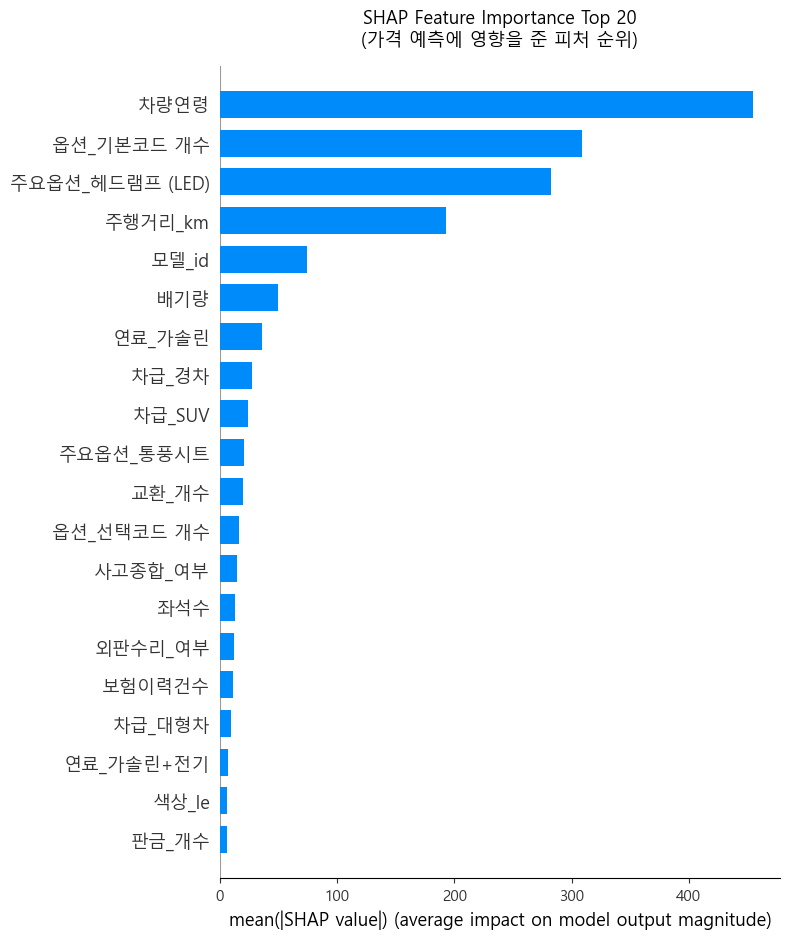

In [20]:
# ── 7-2. 전체 피처 중요도 (Summary Plot) ─────────────────────
# 각 피처가 예측 가격에 얼마나 영향을 미치는지 전체 조망

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    plot_type = 'bar',
    max_display = 20,
    show = False
)
plt.title('SHAP Feature Importance Top 20\n(가격 예측에 영향을 준 피처 순위)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.show()



▶ 고가 예측 사례
  실제가격  : 6,850 만원
  예측가격  : 5,991 만원
  오차      : 859 만원


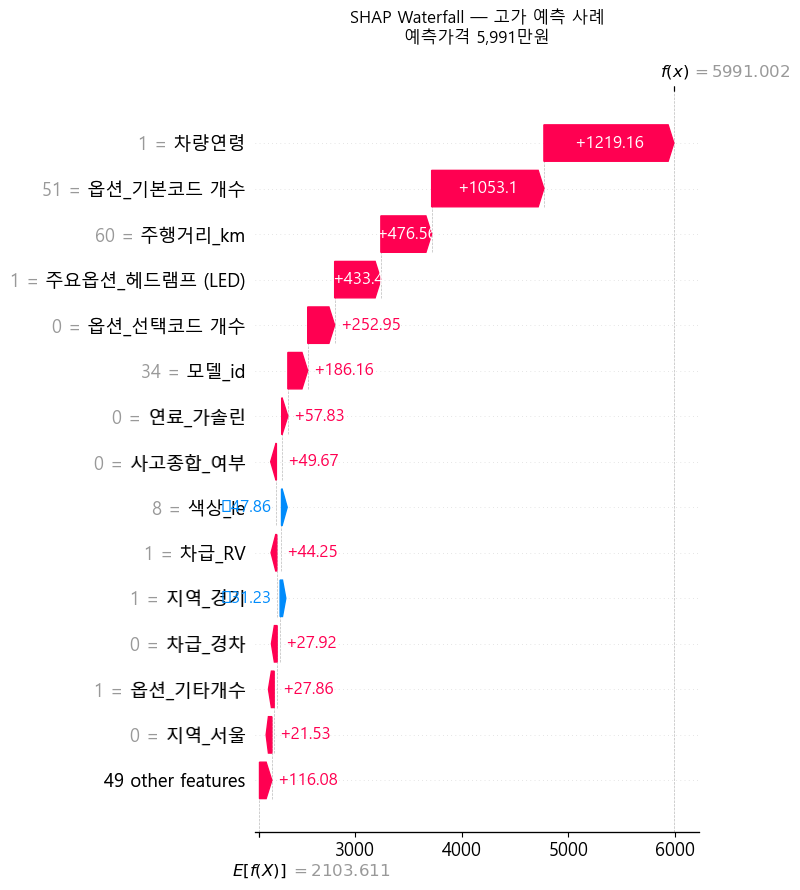


▶ 저가 예측 사례
  실제가격  : 390 만원
  예측가격  : 349 만원
  오차      : 41 만원


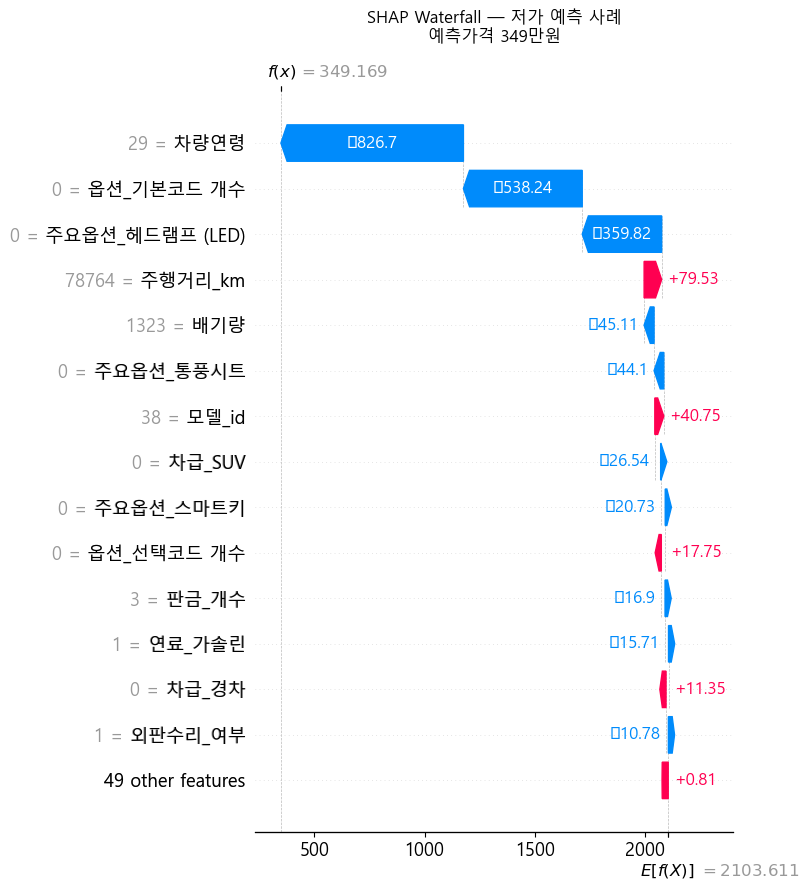

In [21]:
# ── 7-4. 개별 예측 설명 (Waterfall Plot) ─────────────────────
# 특정 매물 1건의 예측 가격이 왜 그렇게 나왔는지 설명
# → 서비스의 "왜 이 가격?" 설명 근거로 활용

# 고가 예측 사례 / 저가 예측 사례 각 1건씩 선택
pred_test   = best_lgb.predict(X_test)
high_idx    = pred_test.argmax()   # 가장 높게 예측된 매물
low_idx     = pred_test.argmin()   # 가장 낮게 예측된 매물

for label, idx in [('고가 예측 사례', high_idx),
                   ('저가 예측 사례', low_idx)]:
    print(f"\n▶ {label}")
    print(f"  실제가격  : {y_test.iloc[idx]:,.0f} 만원")
    print(f"  예측가격  : {pred_test[idx]:,.0f} 만원")
    print(f"  오차      : {abs(y_test.iloc[idx] - pred_test[idx]):,.0f} 만원")

    shap.waterfall_plot(
        shap.Explanation(
            values    = shap_values[idx],
            base_values = explainer.expected_value,
            data      = X_test.iloc[idx],
            feature_names = X_test.columns.tolist()
        ),
        max_display = 15,
        show = False
    )
    plt.title(f'SHAP Waterfall — {label}\n예측가격 {pred_test[idx]:,.0f}만원',
              fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()


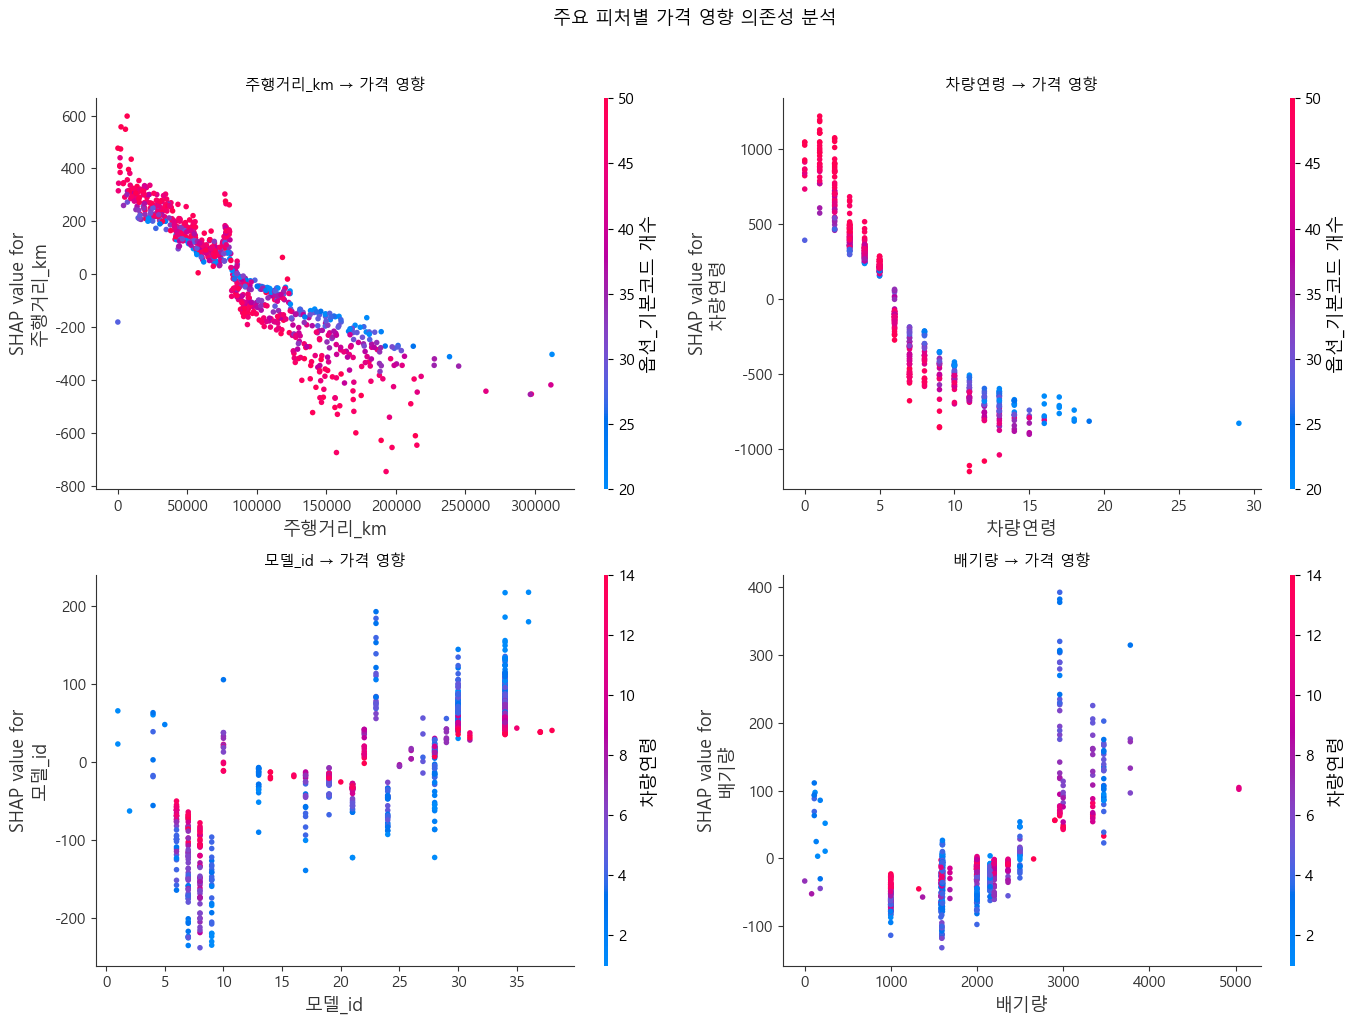

In [22]:
# ── 7-5. 핵심 피처 의존성 분석 (Dependence Plot) ─────────────
# 주행거리 / 차량연령이 가격에 미치는 영향 곡선 확인

key_features = ['주행거리_km', '차량연령', '모델_id', '배기량']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X_test,
        ax   = axes[i],
        show = False
    )
    axes[i].set_title(f'{feat} → 가격 영향', fontsize=11)

plt.suptitle('주요 피처별 가격 영향 의존성 분석', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [24]:
# ── 7-6. SHAP 결과 요약 출력 ─────────────────────────────────
# 상위 10개 피처 영향력 수치 정리

shap_importance = pd.DataFrame({
    '피처'      : X_test.columns,
    'SHAP 평균' : np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP 평균', ascending=False).reset_index(drop=True)

print("=" * 40)
print("  가격 예측 주요 영향 피처 Top 10")
print("=" * 40)
for i, row in shap_importance.head(10).iterrows():
    bar = '█' * int(row['SHAP 평균'] / shap_importance['SHAP 평균'].max() * 20)
    print(f"  {i+1:>2}. {row['피처']:<22} {bar} {row['SHAP 평균']:>6.1f}")
print("=" * 40)


  가격 예측 주요 영향 피처 Top 10
   1. 차량연령                   ████████████████████  454.9
   2. 옵션_기본코드 개수             █████████████  308.8
   3. 주요옵션_헤드램프 (LED)        ████████████  282.5
   4. 주행거리_km                ████████  192.9
   5. 모델_id                  ███   74.3
   6. 배기량                    ██   49.2
   7. 연료_가솔린                 █   36.2
   8. 차급_경차                  █   27.1
   9. 차급_SUV                 █   23.8
  10. 주요옵션_통풍시트                 20.9


In [ ]:
### STEP 7 결과에서 확인할 포인트

| 시각화 | 확인 내용 | 서비스 활용 |
|--------|---------|-----------|
| **Summary Bar** | 가격에 영향 큰 피처 순위 | 중요 입력항목 우선순위 결정 |
| **Beeswarm** | 피처값 높낮이가 가격에 미치는 방향 | 가격 상승/하락 요인 설명 |
| **Waterfall** | 매물 1건의 예측 근거 분해 | "왜 이 가격?" 화면 구현 근거 |
| **Dependence** | 주행거리·연령 따른 가격 변화 곡선 | 가격 변동 요인 안내 UX |

  현재가격과 상관계수 Top 20 (절댓값 순)
  차량연령                     -0.7310  ██████████████
  주요옵션_헤드램프 (LED)          +0.7023  ██████████████
  옵션_기본코드 개수               +0.6901  █████████████
  주행거리_km                  -0.5507  ███████████
  주요옵션_통풍시트                +0.5172  ██████████
  보험이력건수                   -0.3999  ███████
  옵션_선택코드 개수               +0.3884  ███████
  주요옵션_자동에어컨               +0.3852  ███████
  차급_경차                    -0.3782  ███████
  사고종합_여부                  -0.3528  ███████
  주요옵션_스마트키                +0.3522  ███████
  보험이력_여부                  -0.3307  ██████
  연료_가솔린+전기                +0.2872  █████
  주요옵션_내비게이션               +0.2836  █████
  외판수리_여부                  -0.2759  █████
  교환_여부                    -0.2697  █████
  주요옵션_후방카메라               +0.2537  █████
  모델_id                    +0.2512  █████
  교환_개수                    -0.2485  ████
  배기량                      +0.2397  ████


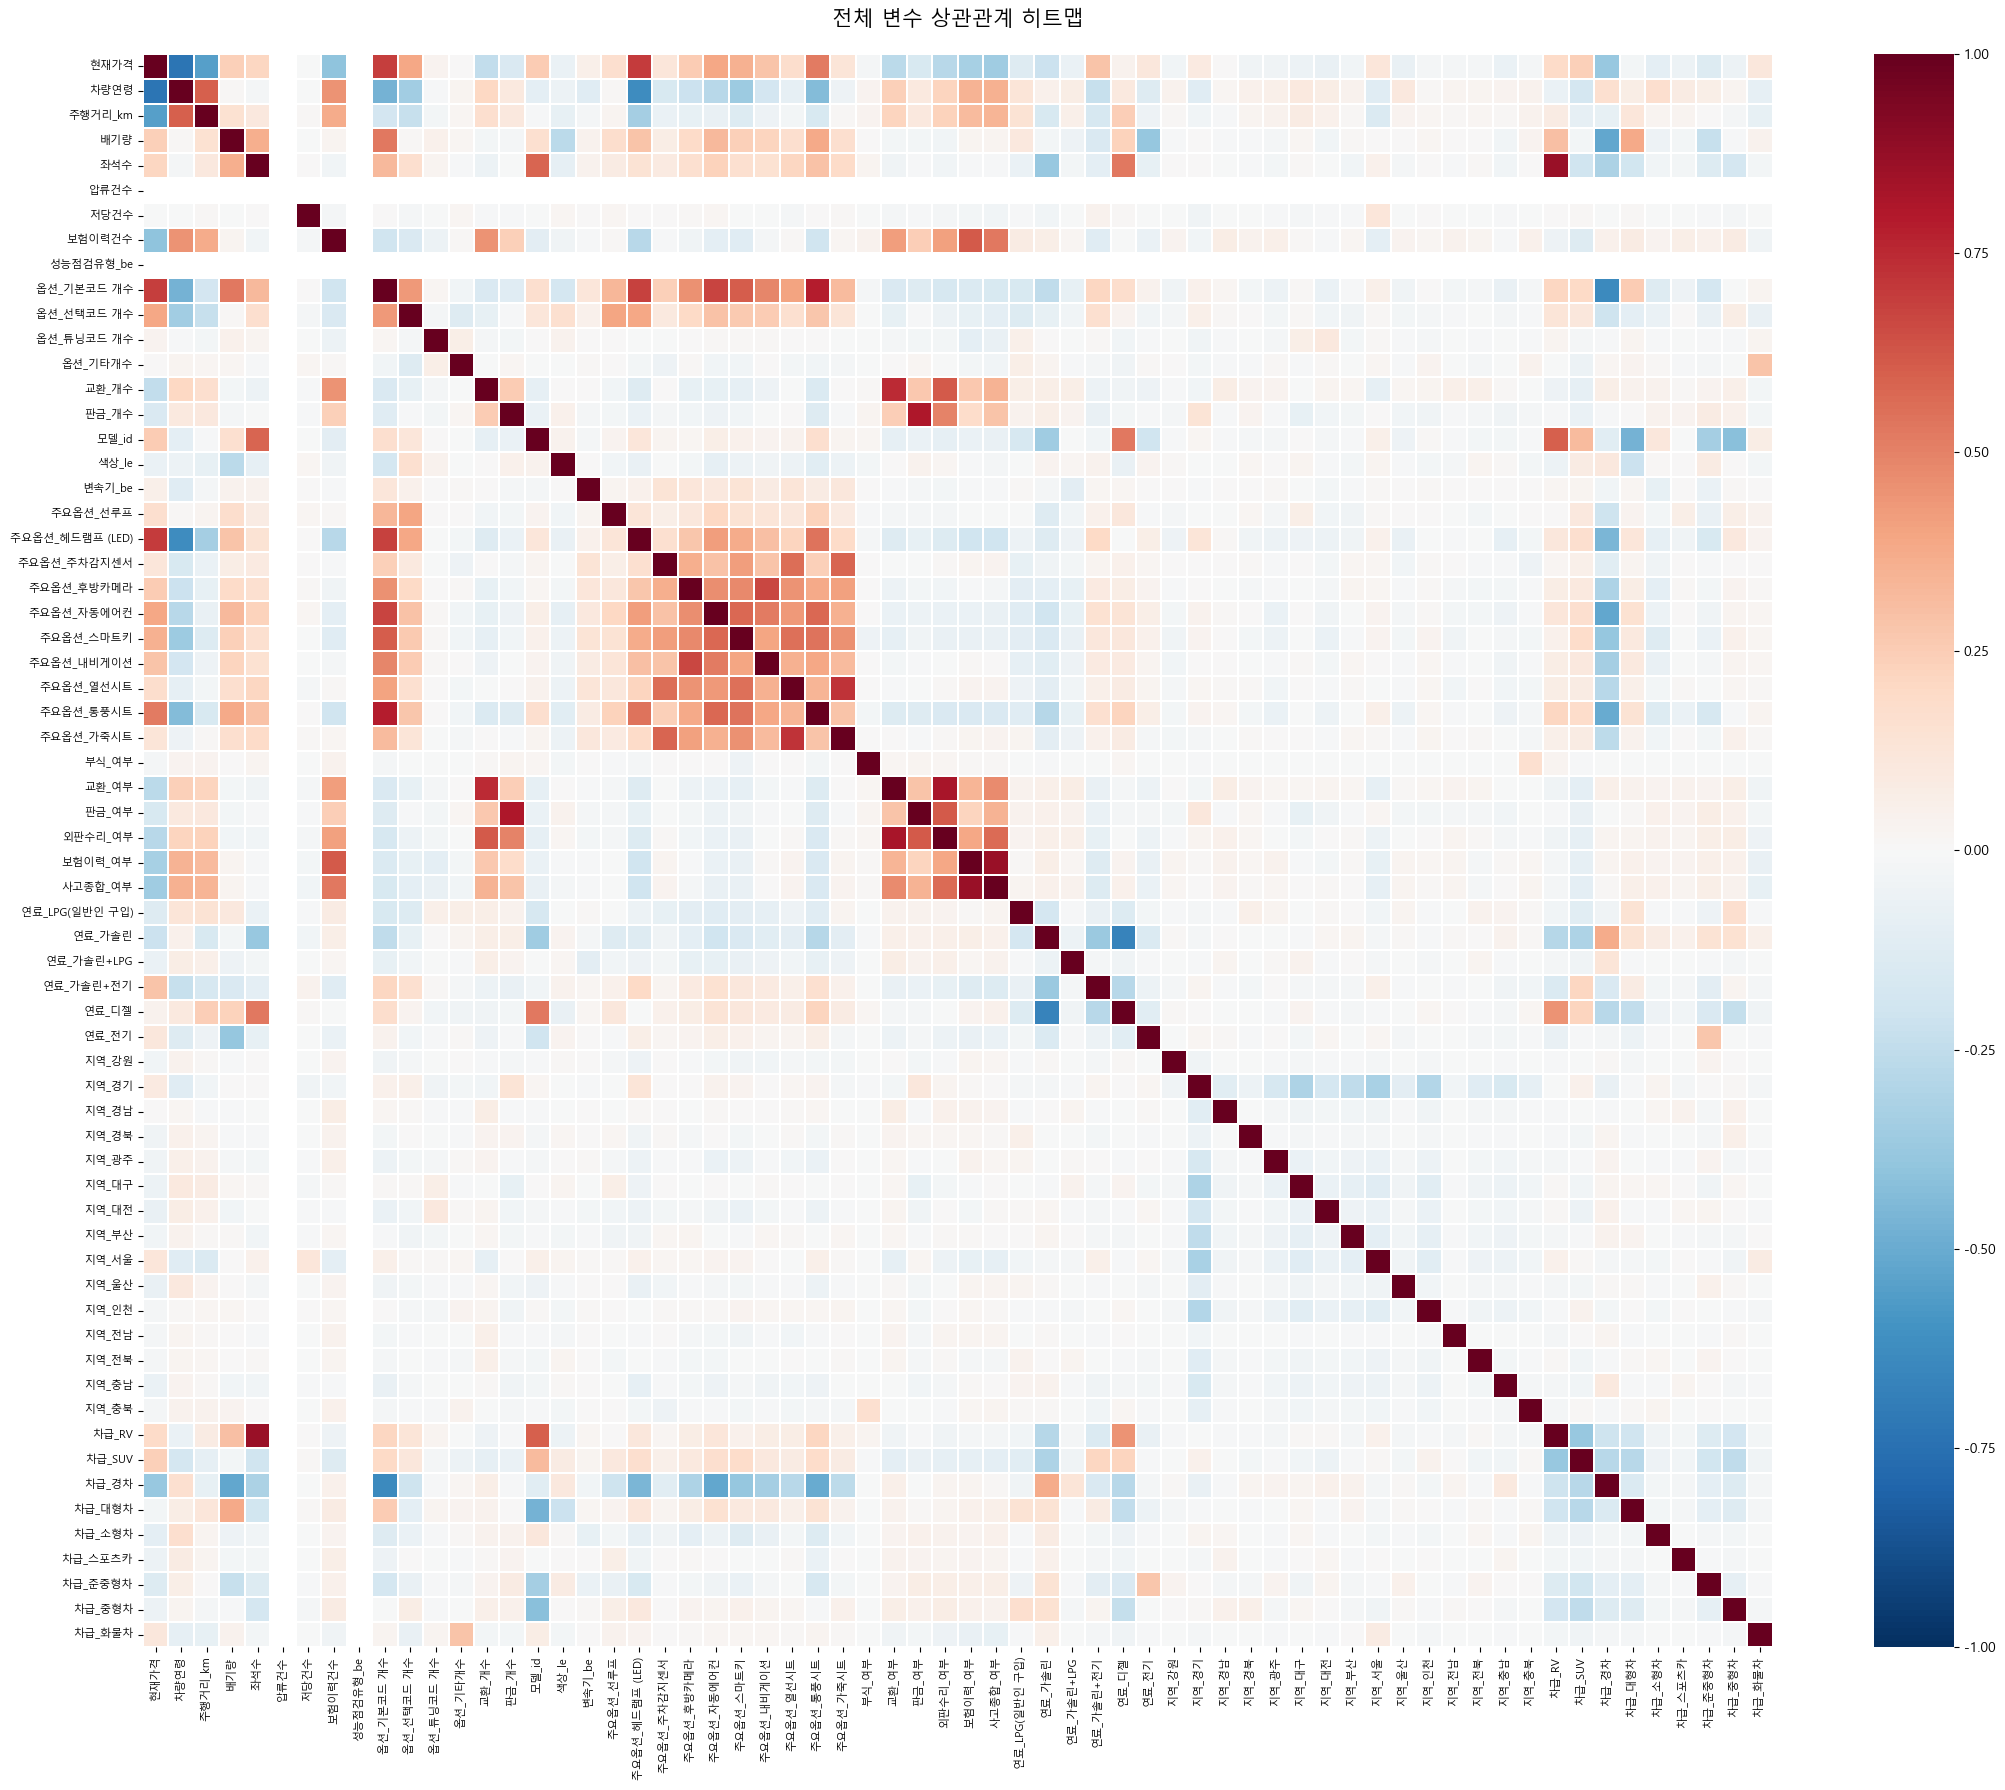

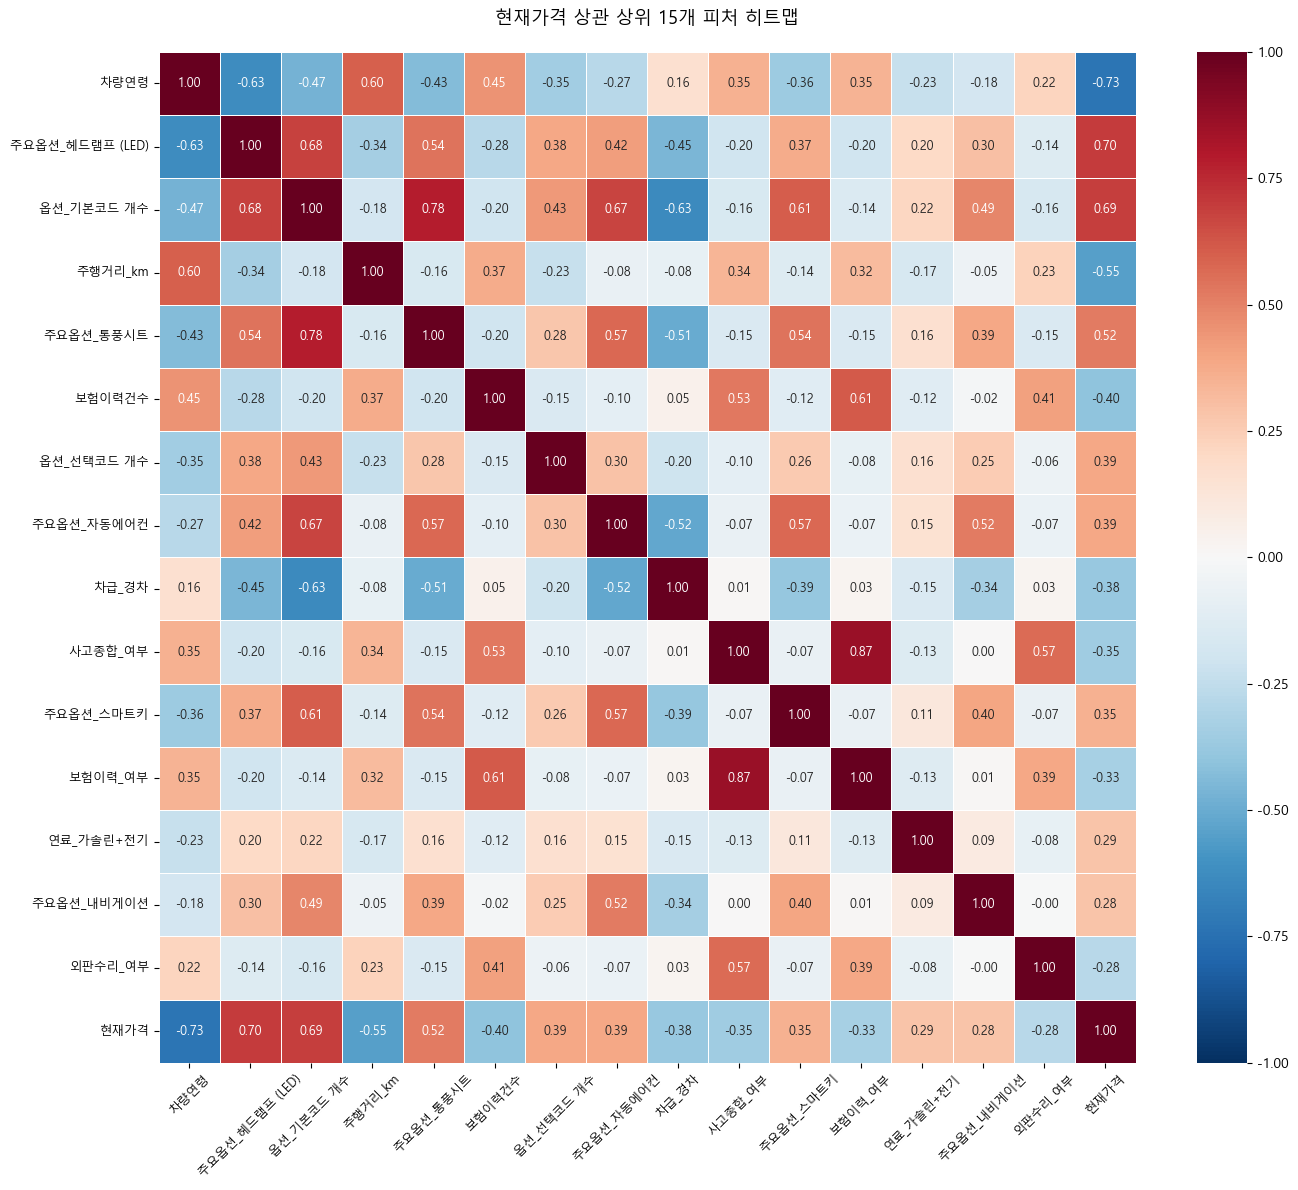

  다중공선성 의심 피처 쌍 (상관계수 |r| ≥ 0.8)
  좌석수                       ↔  차급_RV                     r = 0.8669
  판금_개수                     ↔  판금_여부                     r = 0.8097
  교환_여부                     ↔  외판수리_여부                   r = 0.8244
  보험이력_여부                   ↔  사고종합_여부                   r = 0.8655


In [26]:
# ── 변수 간 상관관계 분석 ─────────────────────────────────────

# ── 1. 상관계수 행렬 계산 ─────────────────────────────────────
corr_matrix = df_clean.drop(columns=['매물ID', '연식']).corr()

# ── 2. 타겟(현재가격)과의 상관계수 순위 ──────────────────────
target_corr = (corr_matrix['현재가격']
               .drop('현재가격')
               .sort_values(key=abs, ascending=False))

print("=" * 45)
print("  현재가격과 상관계수 Top 20 (절댓값 순)")
print("=" * 45)
for feat, val in target_corr.head(20).items():
    bar   = '█' * int(abs(val) * 20)
    sign  = '+' if val > 0 else '-'
    print(f"  {feat:<24} {sign}{abs(val):.4f}  {bar}")
print("=" * 45)

# ── 3. 전체 상관관계 히트맵 ──────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 18))

sns.heatmap(
    corr_matrix,
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1, vmax = 1,
    annot      = False,
    linewidths = 0.3,
    linecolor  = 'white',
    ax         = ax
)

ax.set_title('전체 변수 상관관계 히트맵', fontsize=15, pad=20)
ax.tick_params(axis='x', rotation=90,  labelsize=8)
ax.tick_params(axis='y', rotation=0,   labelsize=8)
plt.tight_layout()
plt.show()

# ── 4. 타겟 상관 상위 15개 피처만 확대 히트맵 ────────────────
top_features = target_corr.head(15).index.tolist() + ['현재가격']
corr_top     = df_clean[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_top,
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1, vmax = 1,
    annot      = True,
    fmt        = '.2f',
    annot_kws  = {'size': 9},
    linewidths = 0.5,
    linecolor  = 'white',
    ax         = ax
)

ax.set_title('현재가격 상관 상위 15개 피처 히트맵', fontsize=13, pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

# ── 5. 다중공선성 의심 피처 탐지 ─────────────────────────────
# 피처 간 상관계수 0.8 이상인 쌍 추출

print("=" * 55)
print("  다중공선성 의심 피처 쌍 (상관계수 |r| ≥ 0.8)")
print("=" * 55)

threshold = 0.8
checked   = set()
found     = False

feat_cols = corr_matrix.drop(columns=['현재가격']).drop(index=['현재가격'])

for col in feat_cols.columns:
    for row in feat_cols.index:
        if col == row:
            continue
        pair = tuple(sorted([col, row]))
        if pair in checked:
            continue
        checked.add(pair)
        val = feat_cols.loc[row, col]
        if abs(val) >= threshold:
            print(f"  {pair[0]:<24}  ↔  {pair[1]:<24}  r = {val:.4f}")
            found = True

if not found:
    print("  해당 없음 (다중공선성 의심 피처 쌍 없음)")
print("=" * 55)



### 결과에서 확인할 포인트

| 항목 | 확인 내용 | 기준 |
|------|---------|------|
| **타겟 상관 Top** | 가격 예측에 유효한 피처 확인 | `\|r\| > 0.3` 이상이면 유의미 |
| **히트맵 전체** | 피처 간 군집 패턴 파악 | 붉은 군집 = 양의 상관 그룹 |
| **다중공선성** | 서로 너무 비슷한 피처 쌍 탐지 | `\|r\| ≥ 0.8` 이면 하나 제거 고려 |